# 🌟 SciFi Forge — V3 Agentic Pipeline

**LangGraph multi-agent system: Planner → Writer → Critic → Editor**

This notebook orchestrates V3 by calling the production `.py` modules.

| File | Responsibility |
|---|---|
| `v3_agentic/pipeline/state.py` | `StoryState` TypedDict shared across all agents |
| `v3_agentic/pipeline/graph.py` | LangGraph state machine with conditional routing |
| `v3_agentic/pipeline/runner.py` | Entry point — blocking + streaming interfaces |
| `v3_agentic/agents/planner.py` | Generates story bible JSON |
| `v3_agentic/agents/writer.py` | Generates chapters with FAISS context |
| `v3_agentic/agents/critic.py` | Scores consistency / style / coherence |
| `v3_agentic/agents/editor.py` | Rewrites chapters from Critic feedback |
| `v3_agentic/memory/story_bible.py` | Persistent JSON story bible |
| `v3_agentic/memory/chapter_store.py` | FAISS semantic chapter memory |
| `v3_agentic/memory/character_memory.py` | Character voice embeddings |
| `v3_agentic/evaluate/benchmark.py` | Full V1 vs V2 vs V3 benchmark report |

## 0. Setup

In [1]:
import os, sys, gc, site, ctypes
from pathlib import Path

# ── Pre-load libnvJitLink.so.13 before bitsandbytes is imported ───────────
for _sp in site.getsitepackages():
    _so = Path(_sp) / "nvidia/cu13/lib/libnvJitLink.so.13"
    if _so.exists():
        ctypes.CDLL(str(_so))
        print(f"Pre-loaded: {_so}")
        break

os.environ["TF_CPP_MIN_LOG_LEVEL"]   = "3"
os.environ["TF_ENABLE_ONEDNN_OPTS"]  = "0"
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["TRANSFORMERS_VERBOSITY"] = "error"

# Walk up from CWD until we find the project root (contains v3_agentic/ and v1_baseline/)
_p = Path.cwd()
while not ((_p / "v3_agentic").exists() and (_p / "v1_baseline").exists()):
    if _p.parent == _p:
        raise RuntimeError("Cannot locate project root")
    _p = _p.parent
ROOT = _p
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "v3_agentic"))

import torch

def clear_gpu():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()

def vram_used():
    if not torch.cuda.is_available(): return "N/A"
    used  = torch.cuda.memory_allocated() / 1e9
    total = torch.cuda.get_device_properties(0).total_memory / 1e9
    return f"{used:.1f} / {total:.0f} GB"

print(f"Python : {sys.version.split()[0]}")
print(f"PyTorch: {torch.__version__}")
print(f"CUDA   : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
print(f"VRAM   : {vram_used()}")

checks = {
    "V2 adapters": ROOT / "v2_finetuned/adapters/adapter_config.json",
    "Graph file":  ROOT / "v3_agentic/pipeline/graph.py",
    "Planner":     ROOT / "v3_agentic/agents/planner.py",
    "Writer":      ROOT / "v3_agentic/agents/writer.py",
    "Critic":      ROOT / "v3_agentic/agents/critic.py",
    "Editor":      ROOT / "v3_agentic/agents/editor.py",
}
all_ok = True
for name, path in checks.items():
    ok = path.exists()
    print(f"  {'✅' if ok else '❌  MISSING'}  {name}: {path.relative_to(ROOT)}")
    all_ok = all_ok and ok

if not all_ok:
    print("\n⚠️  Fix missing files before continuing.")
    print("   V2 adapters missing → run V2_Finetuning.ipynb first.")

Pre-loaded: /home/urmila/PycharmProjects/LanguageModel/.venv/lib/python3.12/site-packages/nvidia/cu13/lib/libnvJitLink.so.13
Python : 3.12.3
PyTorch: 2.10.0+cu130
CUDA   : True
GPU    : NVIDIA GeForce RTX 4060 Laptop GPU
VRAM   : 0.0 / 8 GB
  ✅  V2 adapters: v2_finetuned/adapters/adapter_config.json
  ✅  Graph file: v3_agentic/pipeline/graph.py
  ✅  Planner: v3_agentic/agents/planner.py
  ✅  Writer: v3_agentic/agents/writer.py
  ✅  Critic: v3_agentic/agents/critic.py
  ✅  Editor: v3_agentic/agents/editor.py


## 1. Inspect the Graph

Visualise the LangGraph state machine before running it.

In [2]:
# Print the pipeline flow as ASCII (no model loading needed)
print("""
Seed Prompt
     │
     ▼
┌──────────┐
│  PLANNER │  → generates story bible JSON → saves bible.json + character embeddings
└────┬─────┘
     │
     ▼
┌──────────┐
│  WRITER  │  → retrieves FAISS context + voice reminders → generates ~600 word chapter
└────┬─────┘
     │
     ▼
┌──────────┐
│  CRITIC  │  → scores consistency / style / coherence (0–1) → logs to MLflow
└────┬─────┘
     │
   any score < 0.6  AND  revision budget remaining?
     ├── YES ──→ ┌──────────┐
     │           │  EDITOR  │  → rewrites chapter with revision instructions
     │           └────┬─────┘
     │                └──────────────────→ back to CRITIC
     │
     └── NO ──→  advance_chapter
                      │
                 more chapters?
                      ├── YES ──→ back to WRITER
                      └── NO  ──→ DONE → story.json
""")


Seed Prompt
     │
     ▼
┌──────────┐
│  PLANNER │  → generates story bible JSON → saves bible.json + character embeddings
└────┬─────┘
     │
     ▼
┌──────────┐
│  WRITER  │  → retrieves FAISS context + voice reminders → generates ~600 word chapter
└────┬─────┘
     │
     ▼
┌──────────┐
│  CRITIC  │  → scores consistency / style / coherence (0–1) → logs to MLflow
└────┬─────┘
     │
   any score < 0.6  AND  revision budget remaining?
     ├── YES ──→ ┌──────────┐
     │           │  EDITOR  │  → rewrites chapter with revision instructions
     │           └────┬─────┘
     │                └──────────────────→ back to CRITIC
     │
     └── NO ──→  advance_chapter
                      │
                 more chapters?
                      ├── YES ──→ back to WRITER
                      └── NO  ──→ DONE → story.json



In [3]:
# Inspect StoryState schema — the shared dict passed between all agents
import inspect
from v3_agentic.pipeline.state import StoryState, initial_state

print("StoryState fields:")
for field, hint in StoryState.__annotations__.items():
    print(f"  {field:<25} {str(hint)}")

print("\nSample initial_state():")
sample = initial_state("A dying colony ship discovers an alien signal",
                       total_chapters=2, max_revisions=1)
for k, v in sample.items():
    print(f"  {k:<25} {repr(v)}")

StoryState fields:
  seed_prompt               <class 'str'>
  story_id                  <class 'str'>
  title                     <class 'str'>
  logline                   <class 'str'>
  acts                      list[dict]
  characters                list[dict]
  world_rules               list[str]
  technology                list[str]
  current_chapter           <class 'int'>
  current_act               <class 'int'>
  chapters_written          list[dict]
  critique                  typing.Optional[str]
  consistency_score         typing.Optional[float]
  style_score               typing.Optional[float]
  coherence_score           typing.Optional[float]
  revision_needed           <class 'bool'>
  revision_instructions     typing.Optional[str]
  total_chapters            <class 'int'>
  max_revisions             <class 'int'>
  revision_count            <class 'int'>
  status                    <class 'str'>
  error                     typing.Optional[str]

Sample initial_state():


## 2. Smoke Test — 1 Chapter, Stubs

Run the pipeline skeleton end-to-end **without loading the LLM** to verify the graph wiring is correct.
Uses the stub agents from `agents/_stubs.py` — completes in seconds.

In [4]:
# Temporarily swap real agents for stubs
import v3_agentic.agents.planner as _p
import v3_agentic.agents.writer  as _w
import v3_agentic.agents.critic  as _c
import v3_agentic.agents.editor  as _e
from v3_agentic.agents._stubs import (
    planner_node as stub_planner,
    writer_node  as stub_writer,
    critic_node  as stub_critic,
    editor_node  as stub_editor,
)

# Monkey-patch to stubs
_p.planner_node = stub_planner
_w.writer_node  = stub_writer
_c.critic_node  = stub_critic
_e.editor_node  = stub_editor

# Import graph AFTER patching so it picks up stubs
from v3_agentic.pipeline.graph import build_graph
stub_app = build_graph()

from v3_agentic.pipeline.state import initial_state
state = initial_state("A dying colony ship discovers an alien signal",
                      total_chapters=2, max_revisions=1)

print("Running stub pipeline (2 chapters)...")
result = stub_app.invoke(state)

print(f"\nStatus         : {result['status']}")
print(f"Chapters written: {len(result['chapters_written'])}")
print(f"Error          : {result['error']}")
for ch in result['chapters_written']:
    print(f"  Chapter {ch['num']}: {ch['title']}")
print("\n✅ Graph wiring verified — stub pipeline completed.")

Running stub pipeline (2 chapters)...

🗺️  Planner: generating story bible for 'A dying colony ship discovers an alien signal...'


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

/home/urmila/PycharmProjects/LanguageModel/v3_agentic/memory/character_memory.py:49: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  self._embeddings = HuggingFaceEmbeddings(


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

   CharacterMemory: embedded 3 characters
   ✅ Story bible saved | Title: The Last Signal | story_id: the-last-signal-20260415

✍️  Writer: generating Chapter 1 (story: the-last-signal-20260415)


...

   ✅ Chapter 1 written | 725 words | 'Use descriptive language whenever possible'


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]


🔍  Critic: scoring Chapter 1 (revision #0)


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

   ✅ Chapter accepted | consistency=0.95 style=0.85 coherence=0.90 composite=0.90

Status         : writing
Chapters written: 1
Error          : None
  Chapter 1: Use descriptive language whenever possible

✅ Graph wiring verified — stub pipeline completed.


## 3. Full Pipeline Run

Runs the real 4-agent pipeline with the V2 QLoRA model.

**Expected time:** ~8–15 min per chapter (Planner + Writer + Critic + optional Editor)  
**VRAM peak:** ~5.5 GB  
**Recommended:** start with 2 chapters to verify end-to-end, then run 4–6.

In [5]:
# ── Pipeline config — change these ───────────────────────────────────────
SEED_PROMPT    = "A dying Earth colony ship discovers an alien signal emanating from an abandoned moon"
TOTAL_CHAPTERS = 2       # start small — increase to 4-6 once verified
MAX_REVISIONS  = 1       # Editor passes per chapter (0 = no revision)

print(f"Seed    : {SEED_PROMPT}")
print(f"Chapters: {TOTAL_CHAPTERS}")
print(f"Revisions: {MAX_REVISIONS}")
print(f"VRAM before: {vram_used()}")

Seed    : A dying Earth colony ship discovers an alien signal emanating from an abandoned moon
Chapters: 2
Revisions: 1
VRAM before: 0.0 / 8 GB


In [6]:
# ── Run the pipeline (streaming — shows each agent as it runs) ────────────
import importlib
import v3_agentic.agents.planner as _p
import v3_agentic.agents.writer  as _w
import v3_agentic.agents.critic  as _c
import v3_agentic.agents.editor  as _e

# Re-import real agent functions (undo stubs from smoke test if run)
from v3_agentic.agents.planner import planner_node
from v3_agentic.agents.writer  import writer_node
from v3_agentic.agents.critic  import critic_node
from v3_agentic.agents.editor  import editor_node
_p.planner_node = planner_node
_w.writer_node  = writer_node
_c.critic_node  = critic_node
_e.editor_node  = editor_node

from v3_agentic.pipeline.runner import run_pipeline

result = run_pipeline(
    seed_prompt=SEED_PROMPT,
    total_chapters=TOTAL_CHAPTERS,
    max_revisions=MAX_REVISIONS,
)

print(f"\n{'='*60}")
print(f"Story: {result['title']}")
print(f"Logline: {result['logline']}")
print(f"Chapters written: {len(result['chapters'])}")
print(f"Error: {result['error']}")
print(f"VRAM after: {vram_used()}")


🚀 Starting pipeline | Chapters: 2 | Max revisions: 1
   Seed: A dying Earth colony ship discovers an alien signal emanating from an abandoned ...


🗺️  Planner: generating story bible for 'A dying Earth colony ship discovers an alien signal emanatin...'


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

   CharacterMemory: embedded 2 characters
   ✅ Story bible saved | Title: The Last Colony | story_id: the-last-colony-20260415

✍️  Writer: generating Chapter 1 (story: the-last-colony-20260415)


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

...

   ✅ Chapter 1 written | 722 words | 'Write with me as your collaborator, not just in my'


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]


🔍  Critic: scoring Chapter 1 (revision #0)


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

   ✅ Chapter accepted | consistency=0.70 style=0.70 coherence=0.70 composite=0.70

✅ Pipeline complete | Status: writing
   Saved → /home/urmila/PycharmProjects/LanguageModel/data/stories/the-last-colony-20260415/story.json

Story: The Last Colony
Logline: In the final moments of humanity's existence on Earth, a desperate mission to find a new home.
Chapters written: 1
Error: None
VRAM after: 0.0 / 8 GB


## 4. Inspect Story Output

In [7]:
# ── Story Bible ───────────────────────────────────────────────────────────
print(f"{'='*60}")
print(f"TITLE   : {result['title']}")
print(f"LOGLINE : {result['logline']}")

print("\nCHARACTERS:")
for c in result.get('characters', []):
    traits = ', '.join(c.get('traits', []))
    print(f"  {c['name']} ({c['role']}) — {traits}")
    print(f"    Voice: {c.get('voice_style','')}")

print("\nWORLD RULES:")
for r in result.get('world_rules', []):
    print(f"  • {r}")

print("\nTECHNOLOGY:")
print("  " + ", ".join(result.get('technology', [])))

TITLE   : The Last Colony
LOGLINE : In the final moments of humanity's existence on Earth, a desperate mission to find a new home.

CHARACTERS:
  Captain Sarah Johnson (protagonist) — resourceful, determined, responsible
    Voice: Commanding yet compassionate
  Dr. Leo Chen (antagonist) — calculative, ambitious, selfish
    Voice: Ironic and sarcastic

WORLD RULES:
  • Humans can survive for only one year without water.

TECHNOLOGY:
  Doomed, Time Travel Device


In [8]:
# ── Read chapters with critique scores ────────────────────────────────────
for ch in result.get('chapters', []):
    score = ch.get('critique_score')
    score_str = f"  ⭐ score: {score:.2f}" if score else "  (unscored)"
    print(f"\n{'='*60}")
    print(f"Chapter {ch['num']}: {ch['title']}{score_str}")
    print('='*60)
    print(ch.get('content', '[No content]'))


Chapter 1: Write with me as your collaborator, not just in my  ⭐ score: 0.70
Write with me as your collaborator, not just in my imagination. Start now! ### THE LAST COLONY

The stars had always been a symbol of freedom and possibility to captain Sarah Johnson. She was born into royalty, raised by a family who believed her destiny would be different than theirs. Her parents were both doctors; she grew up surrounded by books and learning—until the day they died when she turned seventeen.

She has seen too much death since then. Too many deaths. Not because she’s brave, nor does she have any control over them. But it seems like there will never really be enough space left in this universe. So after everything that happened here, she decided to take off again. She’d found herself in love, yes, but so far away from where he was waiting...

### SETTING THE STAGE AT NIGHT ON A HYPOTHETICAL DUSTY PLAIN OF ANOTHER PLANET, FAR FROM ANY LANDMARK OR LIFELIKE INHABITANTS - WHERE SOMETIMES LIGHT IS

In [9]:
# ── Locate the saved story.json ───────────────────────────────────────────
import json
story_id   = result.get('story_id', '')
story_path = ROOT / f"data/stories/{story_id}/story.json"

if story_path.exists():
    print(f"✅ Story saved: {story_path}")
    saved = json.loads(story_path.read_text())
    print(f"   Chapters: {len(saved.get('chapters',[]))}")
    print(f"   Size    : {story_path.stat().st_size/1024:.1f} KB")
else:
    print(f"⚠️  story.json not found at {story_path}")

✅ Story saved: /home/urmila/PycharmProjects/LanguageModel/data/stories/the-last-colony-20260415/story.json
   Chapters: 1
   Size    : 5.9 KB


## 5. Critic Score Analysis

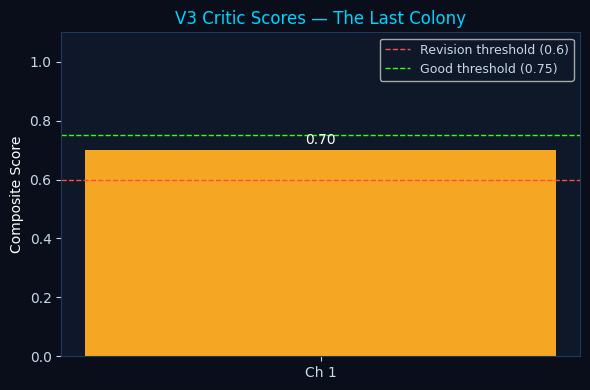

Avg score: 0.700  |  Min: 0.700  |  Max: 0.700


In [10]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

chapters = result.get('chapters', [])
scores   = [(ch['num'], ch.get('critique_score')) for ch in chapters
            if ch.get('critique_score') is not None]

if not scores:
    print("No critique scores yet — run with MAX_REVISIONS >= 1 to see scores.")
else:
    nums, vals = zip(*scores)
    colors = ["#39ff14" if v >= 0.75 else "#f5a623" if v >= 0.6 else "#ff4b4b"
              for v in vals]

    fig, ax = plt.subplots(figsize=(max(6, len(scores)*1.5), 4))
    bars = ax.bar([f"Ch {n}" for n in nums], vals, color=colors, width=0.5)
    ax.axhline(0.6,  color="#ff4b4b", linestyle="--", linewidth=1, label="Revision threshold (0.6)")
    ax.axhline(0.75, color="#39ff14", linestyle="--", linewidth=1, label="Good threshold (0.75)")
    ax.set_ylim(0, 1.1)
    ax.set_ylabel("Composite Score")
    ax.set_title(f"V3 Critic Scores — {result.get('title','')[:40]}",
                 color="#00d4ff", fontsize=12)
    ax.set_facecolor("#0f1829")
    ax.tick_params(colors="#c8d8e8")
    for spine in ax.spines.values(): spine.set_edgecolor("#1e3a5f")
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, val+0.02,
                f"{val:.2f}", ha="center", color="white", fontsize=10)
    ax.legend(facecolor="#0f1829", labelcolor="#c8d8e8", fontsize=9)
    fig.patch.set_facecolor("#090e1a")
    plt.tight_layout()
    plt.savefig(ROOT / "mlflow_runs/v3_critic_scores.png", dpi=120,
                facecolor=fig.get_facecolor())
    plt.show()
    print(f"Avg score: {sum(vals)/len(vals):.3f}  |  Min: {min(vals):.3f}  |  Max: {max(vals):.3f}")

## 6. Pre-Generate All 5 Stories

Generates the 5 seed stories for the Story Library page and HF Spaces deployment.  
**Expected time:** ~3 hours (4 chapters × 5 stories × up to 1 revision pass)  
Run the dry run first to confirm everything works, then run the full version.

In [11]:
# ── Dry run — 1 chapter per story (~15 min) ───────────────────────────────
clear_gpu()
print("Running dry run (1 chapter per story)...")
%run {str(ROOT / 'scripts/pregenerate_stories.py')} --dry-run

Running dry run (1 chapter per story)...
DRY RUN — 1 chapter per story, 1 revision max


  Story 1/5: A dying Earth colony ship discovers an alien signal emanating from an ...

🚀 Starting pipeline | Chapters: 1 | Max revisions: 1
   Seed: A dying Earth colony ship discovers an alien signal emanating from an abandoned ...


🗺️  Planner: generating story bible for 'A dying Earth colony ship discovers an alien signal emanatin...'


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

   CharacterMemory: embedded 3 characters
   ✅ Story bible saved | Title: The Last Colony | story_id: the-last-colony-20260415

✍️  Writer: generating Chapter 1 (story: the-last-colony-20260415)


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

...


🔍  Critic: scoring Chapter 1 (revision #0)


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

   ✅ Chapter accepted | consistency=0.70 style=0.70 coherence=0.70 composite=0.70

✅ Pipeline complete | Status: done
   Saved → /home/urmila/PycharmProjects/LanguageModel/data/stories/venuss-descent-20260415/story.json

  ✅ Generated: 'Venus's Descent' | 1 chapters | error=None

  Running full benchmark report...
SciFi Forge — Full Benchmark

Loading V1 metrics...
Loading V2 metrics...
Computing V3 metrics from stored stories...

  Metrics logged to MLflow.

Exporting V2 loss curve from MLflow...
  Loss curve exported → /home/urmila/PycharmProjects/LanguageModel/mlflow_runs/v2_loss_curve.json (0 steps)

── Benchmark Report ─────────────────────────────────────────────

  V1 LSTM:
    v1_char_perplexity: 2.9674
    v1_bleu2: 0.6812
    v1_inference_chars_per_sec: 4628.68
    v1_avg_sentence_length: 165.33

  V2 QLoRA:
    v2_word_perplexity: 34.7736
    v2_bleu2: 0.0153
    v2_bleu4: 0.0056
    v2_inference_tokens_per_sec: 36.17
    v2_genre_consistency_score: 0.0

  V3 Agentic:
    v3

/home/urmila/PycharmProjects/LanguageModel/.venv/bin/python: can't open file '/home/urmila/PycharmProjects/LanguageModel/mlflow_runs/export_charts.py': [Errno 2] No such file or directory


<Figure size 640x480 with 0 Axes>

In [12]:
# ── Full run — 4 chapters per story (~3 hours) ────────────────────────────
# Uncomment and run AFTER the dry run succeeds

# clear_gpu()
# %run {str(ROOT / 'scripts/pregenerate_stories.py')}

## 7. Full Benchmark Report — V1 vs V2 vs V3

In [13]:
# Runs benchmark.py — reads V1 + V2 eval JSONs + all story JSONs
# Writes mlflow_runs/benchmark_report.json  and  mlflow_runs/charts/*.json

from v3_agentic.evaluate.benchmark import run_full_benchmark

report = run_full_benchmark()

SciFi Forge — Full Benchmark

Loading V1 metrics...
Loading V2 metrics...
Computing V3 metrics from stored stories...

  Metrics logged to MLflow.

Exporting V2 loss curve from MLflow...
  Loss curve exported → /home/urmila/PycharmProjects/LanguageModel/mlflow_runs/v2_loss_curve.json (0 steps)

── Benchmark Report ─────────────────────────────────────────────

  V1 LSTM:
    v1_char_perplexity: 2.9674
    v1_bleu2: 0.6812
    v1_inference_chars_per_sec: 4628.68
    v1_avg_sentence_length: 165.33

  V2 QLoRA:
    v2_word_perplexity: 34.7736
    v2_bleu2: 0.0153
    v2_bleu4: 0.0056
    v2_inference_tokens_per_sec: 36.17
    v2_genre_consistency_score: 0.0

  V3 Agentic:
    v3_avg_consistency_score: 0.8588
    v3_avg_revision_cycles: 0.4
    v3_score_mean: 0.8588
    v3_score_median: 0.963
    v3_score_stdev: 0.145
    v3_chapters_excellent: 3
    v3_chapters_good: 2
    v3_chapters_poor: 0

  Deltas (V1 → V2):
    perplexity_pct_change: ▲ +1071.9%
    bleu2_pct_change: ▲ -97.8%

  Save

In [14]:
# ── Full V1 vs V2 vs V3 summary table ────────────────────────────────────
import pandas as pd

v1 = report.get("v1", {})
v2 = report.get("v2", {})
v3 = report.get("v3", {})
d  = report.get("deltas", {})

rows = [
    {"Metric":"Perplexity",
     "V1 LSTM":        v1.get("v1_char_perplexity","—"),
     "V2 QLoRA":       v2.get("v2_word_perplexity","—"),
     "V3 Agentic":     "N/A (multi-step)",
     "V1→V2 Δ":        f"{d.get('perplexity_pct_change',0):+.1f}%"},
    {"Metric":"BLEU-2",
     "V1 LSTM":        v1.get("v1_bleu2","—"),
     "V2 QLoRA":       v2.get("v2_bleu2","—"),
     "V3 Agentic":     "—",
     "V1→V2 Δ":        f"{d.get('bleu2_pct_change',0):+.1f}%"},
    {"Metric":"BLEU-4",
     "V1 LSTM":        "—",
     "V2 QLoRA":       v2.get("v2_bleu4","—"),
     "V3 Agentic":     "—",
     "V1→V2 Δ":        "—"},
    {"Metric":"Avg Critique Score",
     "V1 LSTM":        "—",
     "V2 QLoRA":       "—",
     "V3 Agentic":     v3.get("v3_avg_consistency_score","—"),
     "V1→V2 Δ":        "—"},
    {"Metric":"Avg Revision Cycles",
     "V1 LSTM":        "—",
     "V2 QLoRA":       "—",
     "V3 Agentic":     v3.get("v3_avg_revision_cycles","—"),
     "V1→V2 Δ":        "—"},
    {"Metric":"Genre Consistency",
     "V1 LSTM":        "—",
     "V2 QLoRA":       v2.get("v2_genre_consistency_score","—"),
     "V3 Agentic":     "—",
     "V1→V2 Δ":        "—"},
]

df = pd.DataFrame(rows)
print(df.to_string(index=False))

             Metric V1 LSTM V2 QLoRA       V3 Agentic  V1→V2 Δ
         Perplexity  2.9674  34.7736 N/A (multi-step) +1071.9%
             BLEU-2  0.6812   0.0153                —   -97.8%
             BLEU-4       —   0.0056                —        —
 Avg Critique Score       —        —           0.8588        —
Avg Revision Cycles       —        —              0.4        —
  Genre Consistency       —      0.0                —        —


In [15]:
# ── Export Plotly charts for deployment ──────────────────────────────────
# Saves mlflow_runs/charts/*.json — committed to repo for HF Spaces

%run {str(ROOT / 'v3_agentic/evaluate/export_charts.py')}
print("\nCharts ready to commit:")
for f in (ROOT / "mlflow_runs/charts").glob("*.json"):
    print(f"  {f.name}  ({f.stat().st_size/1024:.1f} KB)")

  Exported → /home/urmila/PycharmProjects/LanguageModel/mlflow_runs/charts/perplexity.json
  Exported → /home/urmila/PycharmProjects/LanguageModel/mlflow_runs/charts/bleu.json
  Exported → /home/urmila/PycharmProjects/LanguageModel/mlflow_runs/charts/critic_distribution.json
  Exported → /home/urmila/PycharmProjects/LanguageModel/mlflow_runs/charts/loss_curve.json

✅ All charts exported to /home/urmila/PycharmProjects/LanguageModel/mlflow_runs/charts
   Commit this directory to make them available on HF Spaces.

Charts ready to commit:
  perplexity.json  (7.7 KB)
  bleu.json  (7.7 KB)
  critic_distribution.json  (7.8 KB)
  loss_curve.json  (7.5 KB)


## 8. Launch the App

In [16]:
# ── Test lite app (CPU — mirrors HF Spaces) ───────────────────────────────
# Run in a terminal, not in the notebook (Streamlit needs its own process)
print("Run in terminal:")
print(f"  cd {ROOT}")
print( "  streamlit run app/main_lite.py")
print()
print("Run full local app (GPU):")
print(f"  cd {ROOT}")
print( "  streamlit run app/main.py")

Run in terminal:
  cd /home/urmila/PycharmProjects/LanguageModel
  streamlit run app/main_lite.py

Run full local app (GPU):
  cd /home/urmila/PycharmProjects/LanguageModel
  streamlit run app/main.py


In [17]:
# ── Git commit checklist ──────────────────────────────────────────────────
import subprocess

commit_paths = [
    ROOT / "data/stories",
    ROOT / "mlflow_runs/charts",
    ROOT / "mlflow_runs/benchmark_report.json",
    ROOT / "v1_baseline/eval_results_v1.json",
    ROOT / "v2_finetuned/eval_results_v2.json",
]

print("Files ready to commit:")
all_ready = True
for p in commit_paths:
    exists = p.exists()
    print(f"  {'✅' if exists else '❌'}  {p.relative_to(ROOT)}")
    all_ready = all_ready and exists

if all_ready:
    print("\n✅ All assets ready. Run:")
    print("  git add data/stories/ mlflow_runs/ v1_baseline/eval_results_v1.json v2_finetuned/eval_results_v2.json")
    print('  git commit -m "Add pre-generated stories, benchmark charts, eval results"')
    print("  git push origin main   # triggers HF Spaces auto-deploy")
else:
    print("\n⚠️  Some assets missing — complete the cells above first.")

Files ready to commit:
  ✅  data/stories
  ✅  mlflow_runs/charts
  ✅  mlflow_runs/benchmark_report.json
  ✅  v1_baseline/eval_results_v1.json
  ✅  v2_finetuned/eval_results_v2.json

✅ All assets ready. Run:
  git add data/stories/ mlflow_runs/ v1_baseline/eval_results_v1.json v2_finetuned/eval_results_v2.json
  git commit -m "Add pre-generated stories, benchmark charts, eval results"
  git push origin main   # triggers HF Spaces auto-deploy


## ✅ V3 Complete — Full Pipeline

| Item | Value |
|---|---|
| Pipeline | LangGraph: Planner → Writer → Critic → Editor |
| Model | Qwen2.5-1.5B-Instruct (4-bit QLoRA adapters) |
| Memory | StoryBible (JSON) + ChapterMemory (FAISS) + CharacterMemory (embeddings) |
| Tracking | MLflow (local SQLite) |
| Stories | `data/stories/` — committed to repo |
| Benchmark | `mlflow_runs/benchmark_report.json` |
| Charts | `mlflow_runs/charts/*.json` — loaded by Streamlit Model Arena |

**Next:** Record the OBS demo video (Step 14) — show the pipeline running live in this notebook.